# 01. Sparkov Data Audit

This notebook performs the first full audit of the Sparkov credit-card transaction dataset used in this fraud-detection project.

The purpose is to understand the data **before** building models or making final modeling decisions.

## Main Goals

This notebook checks:

- dataset size and structure
- transaction time coverage
- fraud prevalence
- missing values
- duplicate rows and duplicate transaction IDs
- card, merchant, and category coverage
- transaction-amount distributions
- fraud patterns by month, hour, and category
- basic plausibility of age and location-related fields
- output files needed for the rest of the project

## What This Notebook Does Not Do

This notebook does **not**:

- train a machine-learning model
- scale or encode model features
- perform undersampling or SMOTE
- tune thresholds
- calibrate probabilities
- evaluate the final Test set

Those steps are handled in later notebooks.

## Dataset Caution

Sparkov is a **synthetic transaction dataset**.

Therefore, patterns found here describe the simulator and this dataset. They should not automatically be interpreted as real-world customer or fraud behavior.

## Project Sequence

This notebook is the first stage of the project.

The next notebook will create the fixed chronological Train / Calibration / Validation / Test design.

## 1. Import Libraries and Create Output Folders

We use:

- `pandas` for tabular data
- `numpy` for numerical operations
- `matplotlib` for figures

Kaggle allows us to save generated outputs under `/kaggle/working/`.

This notebook will create:

- `/kaggle/working/results`
- `/kaggle/working/figures`

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

os.makedirs("/kaggle/working/results", exist_ok=True)
os.makedirs("/kaggle/working/figures", exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. Load the Sparkov Dataset

The Sparkov CSV used in this project is expected at:

`/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv`

If Kaggle changes the mounted path, update only `DATA_PATH`.

In [2]:
DATA_PATH = "/kaggle/input/datasets/priyamchoksi/credit-card-transactions-dataset/credit_card_transactions.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded.")
print("Raw shape:", df.shape)

Dataset loaded.
Raw shape: (1296675, 24)


## 3. Inspect Both the Beginning and the End

For a time-based dataset, looking only at the first few rows is not enough.

We inspect both:

- `head()` — beginning of the file
- `tail()` — end of the file

This helps us notice whether the dataset appears ordered and whether later rows have the same structure.

In [3]:
display(df.head())

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.970000,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.078800,-81.178100,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,"28,705.000000"
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.230000,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.887800,-118.210500,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.110000,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.180800,-112.262000,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,"83,236.000000"
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.000000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.230600,-112.113800,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.960000,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.420700,-79.462900,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,"22,844.000000"


In [4]:
display(df.tail())

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.560000,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,UT,84735,37.717500,-112.477700,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,NaN
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.700000,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,MD,21790,39.266700,-77.510100,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,"22,630.000000"
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.930000,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,NM,88325,32.939600,-105.818900,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,"88,351.000000"
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.900000,Joseph,Murray,M,42933 Ryan Underpass,Manderson,SD,57756,43.352600,-102.541100,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,"69,367.000000"
1296674,1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.300000,Jeffrey,Smith,M,135 Joseph Mountains,Sula,MT,59871,45.843300,-113.874800,218,"Therapist, horticultural",1995-08-16,8f7c8e4ab7f25875d753b422917c98c9,1371816817,46.565983,-114.186110,0,"59,870.000000"


## 4. Inspect Columns and Data Types

Before cleaning anything, we inspect:

- column names
- number of non-null values
- data types
- approximate memory usage

This provides a first structural overview.

In [5]:
print("Columns:")
for col in df.columns:
    print("-", col)

Columns:
- Unnamed: 0
- trans_date_trans_time
- cc_num
- merchant
- category
- amt
- first
- last
- gender
- street
- city
- state
- zip
- lat
- long
- city_pop
- job
- dob
- trans_num
- unix_time
- merch_lat
- merch_long
- is_fraud
- merch_zipcode


In [6]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

## 5. Remove Accidental Index Columns

CSV files sometimes contain a column such as `Unnamed: 0` when a dataframe index was saved as a normal column.

That field is not a real transaction variable, so it should not be used in analysis or modeling.

In [7]:
unnamed_cols = [
    col for col in df.columns
    if col.lower().startswith("unnamed")
]

print("Unnamed columns:", unnamed_cols)

df = df.drop(
    columns=unnamed_cols,
    errors="ignore"
)

print("Shape after removing index-like columns:", df.shape)

Unnamed columns: ['Unnamed: 0']
Shape after removing index-like columns: (1296675, 23)


## 6. Parse Date and Time Columns

The dataset contains:

- `trans_date_trans_time` — transaction timestamp
- `dob` — date of birth
- `unix_time` — numerical transaction time

We convert the human-readable timestamp and date of birth to pandas datetime values.

Invalid conversions become missing values (`NaT`) so they can be audited explicitly.

In [8]:
df["trans_date_trans_time"] = pd.to_datetime(
    df["trans_date_trans_time"],
    errors="coerce"
)

df["dob"] = pd.to_datetime(
    df["dob"],
    errors="coerce"
)

print(
    "Invalid transaction timestamps:",
    df["trans_date_trans_time"].isna().sum()
)

print(
    "Invalid DOB values:",
    df["dob"].isna().sum()
)

print(
    "Missing unix_time values:",
    df["unix_time"].isna().sum()
)

Invalid transaction timestamps: 0
Invalid DOB values: 0
Missing unix_time values: 0


## 7. Clean Merchant Names

Sparkov merchant strings commonly include a `fraud_` prefix as part of the synthetic generator's naming convention.

That prefix should not be treated as a predictive fraud signal.

We therefore create a cleaned merchant field:

`merchant_clean`

The original `merchant` column is preserved for audit purposes.

In [9]:
merchant_prefix_rate = (
    df["merchant"]
    .astype(str)
    .str.startswith("fraud_")
    .mean()
)

print(
    "Share of merchant strings beginning with 'fraud_':",
    merchant_prefix_rate
)

df["merchant_clean"] = (
    df["merchant"]
    .astype(str)
    .str.replace(
        r"^fraud_",
        "",
        regex=True
    )
)

display(
    df[
        ["merchant", "merchant_clean"]
    ].head()
)

Share of merchant strings beginning with 'fraud_': 1.0


,merchant,merchant_clean
0,"fraud_Rippin, Kub and Mann","Rippin, Kub and Mann"
1,"fraud_Heller, Gutmann and Zieme","Heller, Gutmann and Zieme"
2,fraud_Lind-Buckridge,Lind-Buckridge
3,"fraud_Kutch, Hermiston and Farrell","Kutch, Hermiston and Farrell"
4,fraud_Keeling-Crist,Keeling-Crist


## 8. Sort Transactions Chronologically

Fraud detection is a future-prediction problem, so chronological order is fundamental.

We sort by:

1. `unix_time`
2. `trans_num` as a deterministic tie-breaker

The sorted dataframe becomes the standard transaction order used by the later notebooks.

In [10]:
df = (
    df.sort_values(
        ["unix_time", "trans_num"]
    )
    .reset_index(drop=True)
)

is_sorted = (
    df["unix_time"]
    .is_monotonic_increasing
)

print(
    "Chronologically sorted:",
    is_sorted
)

assert is_sorted

print(
    "Chronological ordering check passed."
)

Chronologically sorted: True
Chronological ordering check passed.


## 9. Audit Time Coverage

We now examine:

- first transaction time
- last transaction time
- total calendar duration

This tells us whether the dataset is suitable for temporal validation and drift analysis.

In [11]:
start_time = (
    df["trans_date_trans_time"].min()
)

end_time = (
    df["trans_date_trans_time"].max()
)

duration = (
    end_time - start_time
)

print("Start:", start_time)
print("End:", end_time)
print("Duration:", duration)
print("Approximate days:", duration.total_seconds() / 86400)

Start: 2019-01-01 00:00:18
End: 2020-06-21 12:13:37
Duration: 537 days 12:13:19
Approximate days: 537.5092476851852


## 10. Target Distribution

The target is:

`is_fraud`

where:

- `0` = legitimate transaction
- `1` = fraudulent transaction

Fraud datasets are usually highly imbalanced, so we calculate both the count and prevalence.

This is one reason why later notebooks emphasize **PR-AUC** rather than accuracy.

In [12]:
class_distribution = (
    df["is_fraud"]
    .value_counts()
    .sort_index()
    .rename_axis("is_fraud")
    .reset_index(name="count")
)

class_distribution["percentage"] = (
    class_distribution["count"]
    / len(df)
    * 100
)

display(class_distribution)

fraud_count = int(
    df["is_fraud"].sum()
)

fraud_rate = float(
    df["is_fraud"].mean()
)

print("Fraud count:", fraud_count)
print("Fraud rate:", fraud_rate)
print("Fraud percentage:", fraud_rate * 100)

,is_fraud,count,percentage
0,0,1289169,99.421135
1,1,7506,0.578865


Fraud count: 7506
Fraud rate: 0.005788651743883394
Fraud percentage: 0.5788651743883394


### Visualize the class imbalance

The chart makes the scale difference between legitimate and fraudulent transactions immediately visible.

A model that predicts almost everything as legitimate could achieve high accuracy, which is why accuracy will not be the primary metric later.

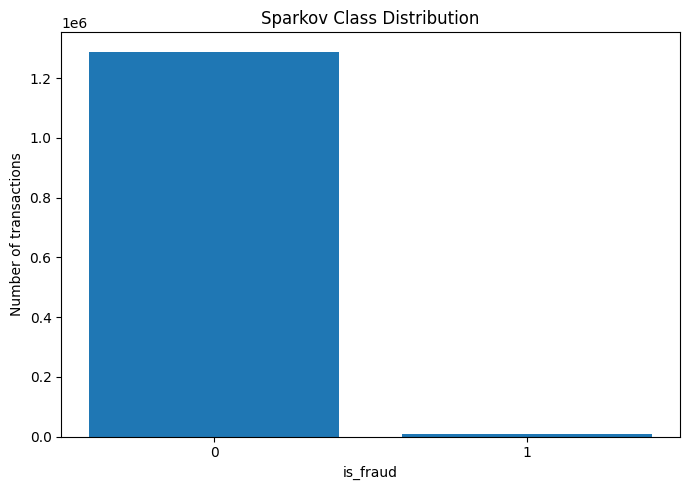

In [13]:
plt.figure(figsize=(7, 5))

plt.bar(
    class_distribution["is_fraud"].astype(str),
    class_distribution["count"]
)

plt.xlabel("is_fraud")
plt.ylabel("Number of transactions")
plt.title("Sparkov Class Distribution")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "class_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 11. Missing-Value Audit

Missingness can affect both feature engineering and model preprocessing.

For each column we calculate:

- missing count
- missing percentage

A missing value is not automatically an error.

For example, some fields may simply be unavailable for a subset of transactions.

In [14]:
missing_values = pd.DataFrame({
    "column": df.columns,
    "missing_count": [
        df[col].isna().sum()
        for col in df.columns
    ],
})

missing_values["missing_percentage"] = (
    missing_values["missing_count"]
    / len(df)
    * 100
)

missing_values = (
    missing_values
    .sort_values(
        "missing_percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    missing_values[
        missing_values["missing_count"] > 0
    ]
)

,column,missing_count,missing_percentage
0,merch_zipcode,195973,15.113502


## 12. Duplicate Audit

We check two different kinds of duplication.

### Exact duplicate rows

Every column in two rows is identical.

### Duplicate transaction IDs

`trans_num` should identify individual transactions.

If the same transaction ID appears more than once, later splitting and evaluation could double-count a transaction.

In [15]:
exact_duplicate_rows = int(
    df.duplicated().sum()
)

duplicate_transaction_ids = int(
    df["trans_num"]
    .duplicated()
    .sum()
)

duplicate_summary = pd.DataFrame([
    {
        "check": "exact_duplicate_rows",
        "count": exact_duplicate_rows,
    },
    {
        "check": "duplicate_transaction_ids",
        "count": duplicate_transaction_ids,
    },
])

display(duplicate_summary)

print(
    "Exact duplicate rows:",
    exact_duplicate_rows
)

print(
    "Duplicate transaction IDs:",
    duplicate_transaction_ids
)

,check,count
0,exact_duplicate_rows,0
1,duplicate_transaction_ids,0


Exact duplicate rows: 0
Duplicate transaction IDs: 0


### Why transaction-ID uniqueness matters

Later notebooks compare Train, Calibration, Validation, and Test.

If one transaction ID appeared in multiple periods, that would invalidate the temporal experiment.

Notebook 02 will perform another split-specific overlap check.

## 13. Entity and Category Coverage

Fraud systems often depend on repeated behavior from entities such as cards and merchants.

We therefore count:

- unique cards
- unique merchants
- unique categories
- states
- jobs

This also tells us whether later past-only behavioral features are feasible.

In [16]:
entity_summary = pd.DataFrame([
    {
        "entity": "cards",
        "unique_count": df["cc_num"].nunique(),
    },
    {
        "entity": "merchants",
        "unique_count": df["merchant_clean"].nunique(),
    },
    {
        "entity": "categories",
        "unique_count": df["category"].nunique(),
    },
    {
        "entity": "states",
        "unique_count": df["state"].nunique(),
    },
    {
        "entity": "jobs",
        "unique_count": df["job"].nunique(),
    },
])

display(entity_summary)

,entity,unique_count
0,cards,983
1,merchants,693
2,categories,14
3,states,51
4,jobs,494


## 14. Transactions per Card and Merchant

A historical feature such as "average previous card amount" is only useful when an entity has repeated observations.

We summarize transaction counts per:

- card
- merchant

The distribution is more informative than the average alone.

In [17]:
transactions_per_card = (
    df.groupby("cc_num")
    .size()
    .rename("transactions")
)

transactions_per_merchant = (
    df.groupby("merchant_clean")
    .size()
    .rename("transactions")
)

entity_frequency_summary = pd.DataFrame([
    {
        "entity": "card",
        "min": transactions_per_card.min(),
        "median": transactions_per_card.median(),
        "mean": transactions_per_card.mean(),
        "max": transactions_per_card.max(),
    },
    {
        "entity": "merchant",
        "min": transactions_per_merchant.min(),
        "median": transactions_per_merchant.median(),
        "mean": transactions_per_merchant.mean(),
        "max": transactions_per_merchant.max(),
    },
])

display(entity_frequency_summary)

,entity,min,median,mean,max
0,card,7,"1,054.000000","1,319.099695",3123
1,merchant,727,"1,863.000000","1,871.103896",4403


## 15. Audit Transaction Amounts

Transaction amount is important for two different reasons.

### Predictive feature

Large or unusual amounts may contain fraud signal.

### Economic proxy

Later notebooks use transaction amount as a **proxy for potential missed-fraud loss**.

It is not actual realized bank loss.

We first summarize the amount distribution for legitimate and fraudulent transactions.

In [18]:
amount_summary = (
    df.groupby("is_fraud")["amt"]
    .agg([
        "count",
        "mean",
        "std",
        "min",
        "median",
        "max",
    ])
    .reset_index()
)

display(amount_summary)

,is_fraud,count,mean,std,min,median,max
0,0,1289169,67.667110,154.007971,1.000000,47.280000,"28,948.900000"
1,1,7506,531.320092,390.560070,1.060000,396.505000,"1,376.040000"


### Log-transformed amount visualization

Transaction amounts are strongly right-skewed.

Plotting `log1p(amt)` makes the distribution easier to inspect while preserving zero and small values.

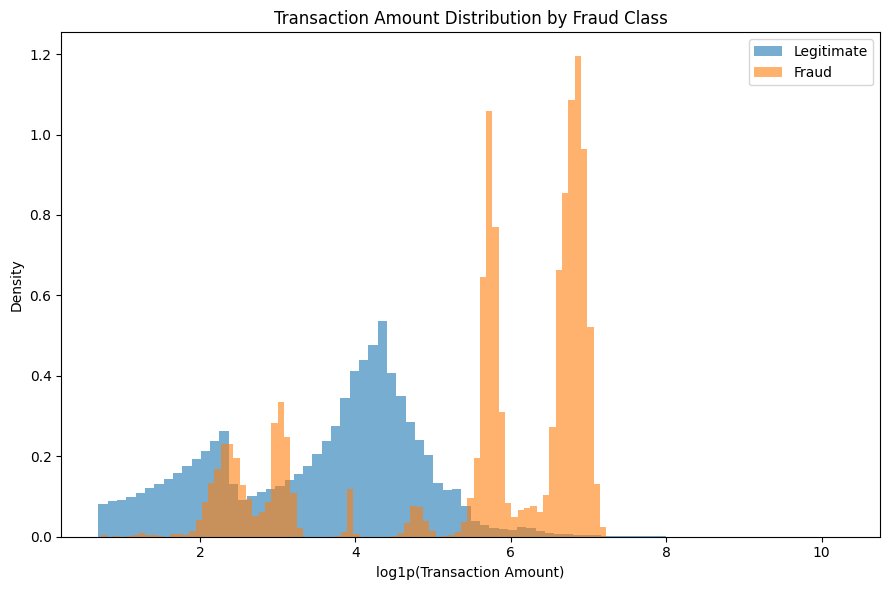

In [19]:
df["_log1p_amt"] = np.log1p(
    df["amt"]
)

plt.figure(figsize=(9, 6))

plt.hist(
    df.loc[
        df["is_fraud"] == 0,
        "_log1p_amt"
    ],
    bins=80,
    alpha=0.6,
    density=True,
    label="Legitimate"
)

plt.hist(
    df.loc[
        df["is_fraud"] == 1,
        "_log1p_amt"
    ],
    bins=80,
    alpha=0.6,
    density=True,
    label="Fraud"
)

plt.xlabel("log1p(Transaction Amount)")
plt.ylabel("Density")
plt.title("Transaction Amount Distribution by Fraud Class")
plt.legend()

plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "amount_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 16. Basic Age Plausibility Check

Age is not provided directly, but it can be calculated from date of birth and transaction date.

This is only a data-quality audit.

We are checking whether the generated ages look numerically plausible, not making any fairness or protected-class claims.

In [20]:
df["_age_years"] = (
    (
        df["trans_date_trans_time"]
        - df["dob"]
    ).dt.days
    / 365.25
)

age_summary = df["_age_years"].describe(
    percentiles=[
        0.01,
        0.05,
        0.50,
        0.95,
        0.99,
    ]
)

display(age_summary.to_frame("age_years"))

print(
    "Age < 0 count:",
    int((df["_age_years"] < 0).sum())
)

print(
    "Age > 120 count:",
    int((df["_age_years"] > 120).sum())
)

,age_years
count,"1,296,675.000000"
mean,45.996399
std,17.394022
min,13.921971
1%,16.878850
5%,21.754962
50%,43.969884
95%,79.630390
99%,91.323751
max,95.638604


Age < 0 count: 0
Age > 120 count: 0


## 17. Basic Geographic Plausibility Check

The dataset contains:

- cardholder latitude / longitude
- merchant latitude / longitude

This audit checks numerical ranges only.

It does not attempt to verify whether each synthetic location corresponds to a real person or merchant.

In [21]:
coordinate_summary = pd.DataFrame({
    "column": [
        "lat",
        "long",
        "merch_lat",
        "merch_long",
    ],
    "min": [
        df["lat"].min(),
        df["long"].min(),
        df["merch_lat"].min(),
        df["merch_long"].min(),
    ],
    "max": [
        df["lat"].max(),
        df["long"].max(),
        df["merch_lat"].max(),
        df["merch_long"].max(),
    ],
})

display(coordinate_summary)

assert df["lat"].between(-90, 90).all()
assert df["merch_lat"].between(-90, 90).all()
assert df["long"].between(-180, 180).all()
assert df["merch_long"].between(-180, 180).all()

print("Coordinate range checks passed.")

,column,min,max
0,lat,20.027100,66.693300
1,long,-165.672300,-67.950300
2,merch_lat,19.027785,67.510267
3,merch_long,-166.671242,-66.950902


Coordinate range checks passed.


## 18. Monthly Transaction and Fraud Summary

Temporal validation requires understanding how transaction volume and fraud prevalence change over time.

We aggregate by calendar month and calculate:

- total transactions
- fraud count
- fraud rate
- total transaction amount
- fraud transaction amount

This is descriptive analysis only.

The final Test period is not yet defined; Notebook 02 will lock the temporal split.

In [22]:
df["month"] = (
    df["trans_date_trans_time"]
    .dt.to_period("M")
    .astype(str)
)

monthly_summary = (
    df.groupby("month")
    .agg(
        transactions=(
            "is_fraud",
            "size"
        ),
        frauds=(
            "is_fraud",
            "sum"
        ),
        total_amount=(
            "amt",
            "sum"
        ),
    )
    .reset_index()
)

monthly_fraud_amount = (
    df.loc[
        df["is_fraud"] == 1
    ]
    .groupby("month")["amt"]
    .sum()
    .rename("fraud_amount")
    .reset_index()
)

monthly_summary = (
    monthly_summary
    .merge(
        monthly_fraud_amount,
        on="month",
        how="left"
    )
)

monthly_summary["fraud_amount"] = (
    monthly_summary["fraud_amount"]
    .fillna(0)
)

monthly_summary["fraud_rate"] = (
    monthly_summary["frauds"]
    / monthly_summary["transactions"]
)

display(monthly_summary)

,month,transactions,frauds,total_amount,fraud_amount,fraud_rate
0,2019-01,52525,506,"3,759,750.030000","261,780.380000",0.009634
1,2019-02,49866,517,"3,604,662.230000","274,051.080000",0.010368
2,2019-03,70939,494,"5,027,886.400000","237,637.590000",0.006964
3,2019-04,68078,376,"4,761,504.580000","202,067.290000",0.005523
4,2019-05,72532,408,"5,060,903.320000","210,549.110000",0.005625
5,2019-06,86064,354,"6,036,397.420000","178,204.600000",0.004113
6,2019-07,86596,331,"6,044,026.740000","188,701.590000",0.003822
7,2019-08,87359,382,"6,047,288.650000","203,951.130000",0.004373
8,2019-09,70652,418,"4,949,834.420000","217,675.370000",0.005916
9,2019-10,68758,454,"4,851,267.370000","257,739.720000",0.006603


### Monthly fraud-rate visualization

A changing fraud rate over time is one reason random Train/Test splitting can be misleading.

The goal of the later temporal split is to evaluate performance on genuinely later periods.

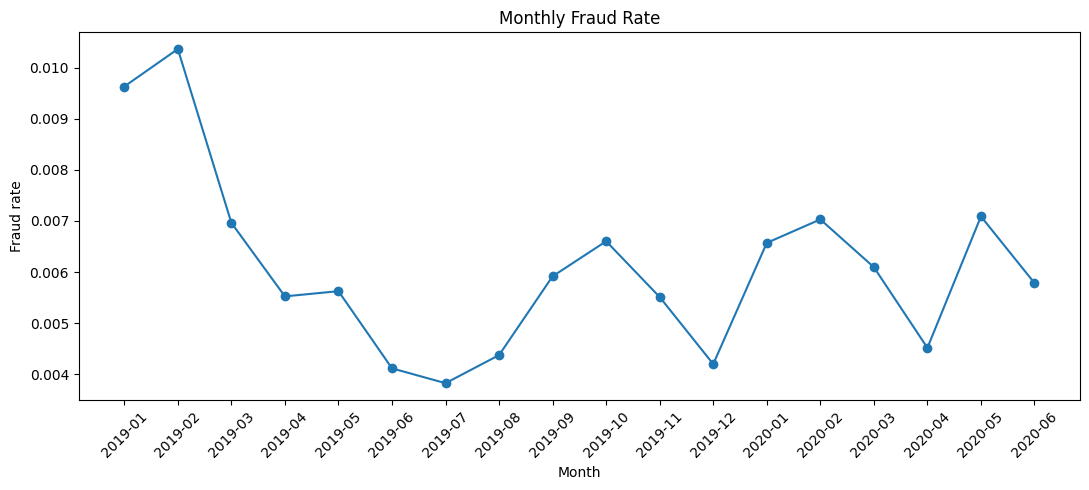

In [23]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_summary["month"],
    monthly_summary["fraud_rate"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Fraud rate")
plt.title("Monthly Fraud Rate")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "monthly_fraud_rate.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 19. Fraud Pattern by Hour of Day

We calculate fraud rate by transaction hour.

This is descriptive EDA.

Later models may use hour-of-day features, but this notebook does not fit any model.

In [24]:
df["hour"] = (
    df["trans_date_trans_time"]
    .dt.hour
)

hourly_summary = (
    df.groupby("hour")
    .agg(
        transactions=(
            "is_fraud",
            "size"
        ),
        frauds=(
            "is_fraud",
            "sum"
        ),
    )
    .reset_index()
)

hourly_summary["fraud_rate"] = (
    hourly_summary["frauds"]
    / hourly_summary["transactions"]
)

display(hourly_summary)

,hour,transactions,frauds,fraud_rate
0,0,42502,635,0.014940
1,1,42869,658,0.015349
2,2,42656,625,0.014652
3,3,42769,609,0.014239
4,4,41863,46,0.001099
5,5,42171,60,0.001423
6,6,42300,40,0.000946
7,7,42203,56,0.001327
8,8,42505,49,0.001153
9,9,42185,47,0.001114


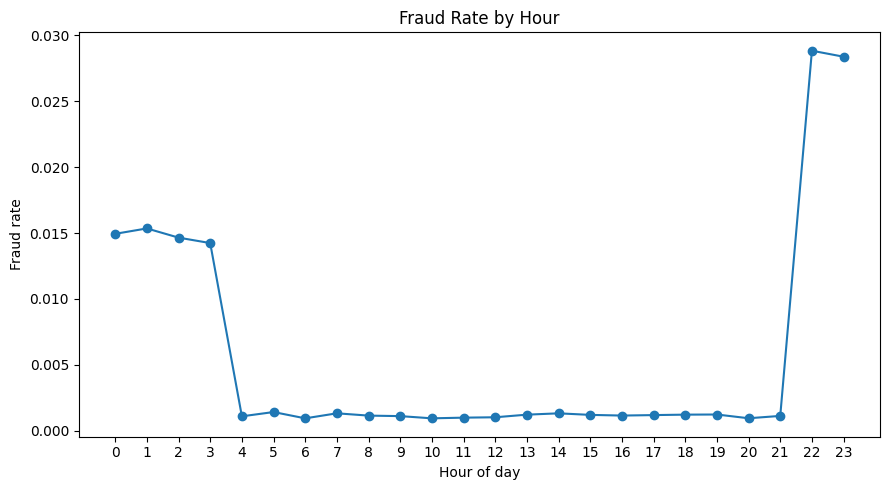

In [25]:
plt.figure(figsize=(9, 5))

plt.plot(
    hourly_summary["hour"],
    hourly_summary["fraud_rate"],
    marker="o"
)

plt.xlabel("Hour of day")
plt.ylabel("Fraud rate")
plt.title("Fraud Rate by Hour")

plt.xticks(range(0, 24))

plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "fraud_rate_by_hour.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 20. Fraud Pattern by Transaction Category

We summarize each category by:

- transaction count
- fraud count
- fraud rate
- total amount
- fraud amount

A high fraud rate in this synthetic dataset should not be interpreted as evidence that the same real-world category is inherently risky.

In [26]:
category_summary = (
    df.groupby("category")
    .agg(
        transactions=(
            "is_fraud",
            "size"
        ),
        frauds=(
            "is_fraud",
            "sum"
        ),
        total_amount=(
            "amt",
            "sum"
        ),
    )
    .reset_index()
)

category_fraud_amount = (
    df.loc[
        df["is_fraud"] == 1
    ]
    .groupby("category")["amt"]
    .sum()
    .rename("fraud_amount")
    .reset_index()
)

category_summary = (
    category_summary
    .merge(
        category_fraud_amount,
        on="category",
        how="left"
    )
)

category_summary["fraud_amount"] = (
    category_summary["fraud_amount"]
    .fillna(0)
)

category_summary["fraud_rate"] = (
    category_summary["frauds"]
    / category_summary["transactions"]
)

category_summary = (
    category_summary
    .sort_values(
        "fraud_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

display(category_summary)

,category,transactions,frauds,total_amount,fraud_amount,fraud_rate
0,shopping_net,97543,1713,"8,625,149.680000","1,711,723.710000",0.017561
1,misc_net,63287,915,"5,117,709.260000","729,266.760000",0.014458
2,grocery_pos,123638,1743,"14,460,822.380000","543,797.900000",0.014098
3,shopping_pos,116672,843,"9,307,993.610000","739,245.090000",0.007225
4,gas_transport,131659,618,"8,351,732.290000","7,594.110000",0.004694
5,misc_pos,79655,250,"5,009,582.500000","54,571.020000",0.003139
6,grocery_net,45452,134,"2,439,412.680000","1,629.820000",0.002948
7,travel,40507,116,"4,516,721.680000","1,051.490000",0.002864
8,entertainment,94014,233,"6,036,678.560000","117,323.790000",0.002478
9,personal_care,90758,220,"4,353,450.530000","5,757.520000",0.002424


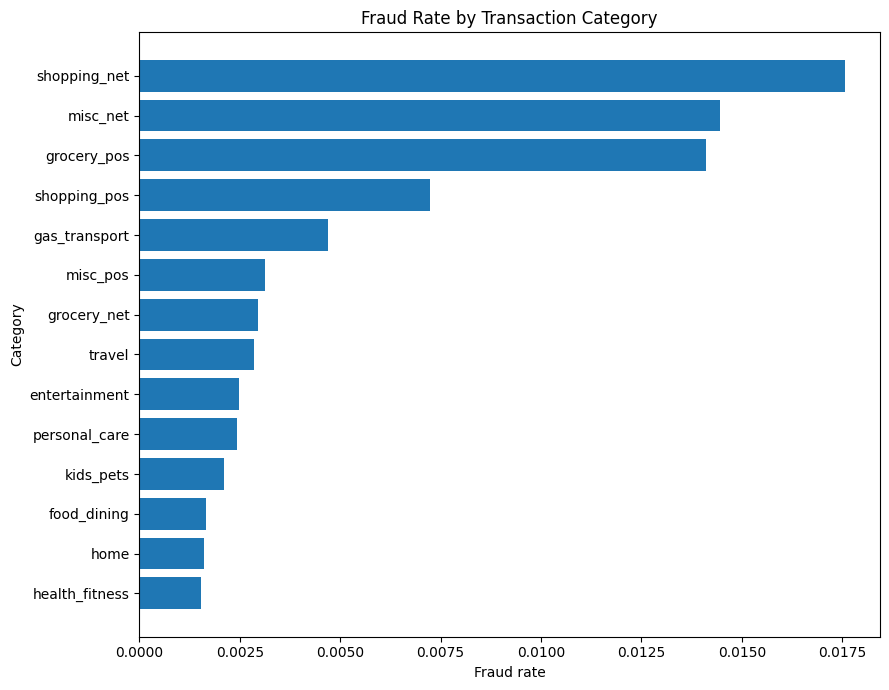

In [27]:
plot_category = (
    category_summary
    .sort_values(
        "fraud_rate",
        ascending=True
    )
)

plt.figure(figsize=(9, 7))

plt.barh(
    plot_category["category"],
    plot_category["fraud_rate"]
)

plt.xlabel("Fraud rate")
plt.ylabel("Category")
plt.title("Fraud Rate by Transaction Category")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/figures/"
    "fraud_rate_by_category.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 21. Fraud-Event Temporal Proximity Audit

This project later uses a purge window between adjacent temporal splits.

One motivation is that fraud transactions may occur in temporally concentrated episodes.

To inspect this, we calculate the gap between consecutive fraud transactions **for the same card**.

This is only a descriptive audit. It does not train a model.

In [28]:
fraud_rows = (
    df.loc[
        df["is_fraud"] == 1,
        [
            "cc_num",
            "unix_time",
            "trans_date_trans_time",
            "trans_num",
        ]
    ]
    .sort_values(
        [
            "cc_num",
            "unix_time",
            "trans_num",
        ]
    )
    .copy()
)

fraud_rows[
    "previous_fraud_unix_time"
] = (
    fraud_rows.groupby(
        "cc_num"
    )["unix_time"]
    .shift(1)
)

fraud_rows[
    "hours_since_previous_fraud_same_card"
] = (
    fraud_rows["unix_time"]
    - fraud_rows[
        "previous_fraud_unix_time"
    ]
) / 3600.0

fraud_gap_summary = (
    fraud_rows[
        "hours_since_previous_fraud_same_card"
    ]
    .dropna()
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

display(
    fraud_gap_summary.to_frame(
        "hours_between_same-card_frauds"
    )
)

within_24h = (
    fraud_rows[
        "hours_since_previous_fraud_same_card"
    ]
    .dropna()
    .le(24)
    .mean()
)

print(
    "Share of consecutive same-card fraud gaps <= 24 hours:",
    within_24h
)

,hours_between_same-card_frauds
count,"6,744.000000"
mean,4.582455
std,6.694936
min,0.000278
10%,0.118056
25%,0.360486
50%,1.087083
75%,5.866250
90%,18.108861
95%,20.221361


Share of consecutive same-card fraud gaps <= 24 hours: 0.9970344009489917


### Interpretation

If many same-card fraud events occur close together, placing transactions immediately adjacent across a split boundary can make Train and future evaluation periods unusually similar.

Notebook 02 therefore introduces a purge window around split boundaries.

After Notebook 02 locks the split, later model decisions should not be changed simply because of Test-period behavior.

## 22. Create a Compact Dataset Summary

We now create one table containing the most important dataset-level facts.

This file is useful for:

- README documentation
- project reports
- later notebook checks

In [29]:
data_summary = pd.DataFrame([
    {
        "metric": "rows",
        "value": len(df),
    },
    {
        "metric": "columns_after_cleaning",
        "value": df.shape[1],
    },
    {
        "metric": "start_time",
        "value": str(start_time),
    },
    {
        "metric": "end_time",
        "value": str(end_time),
    },
    {
        "metric": "duration_days",
        "value": duration.total_seconds() / 86400,
    },
    {
        "metric": "fraud_count",
        "value": fraud_count,
    },
    {
        "metric": "fraud_rate",
        "value": fraud_rate,
    },
    {
        "metric": "unique_cards",
        "value": df["cc_num"].nunique(),
    },
    {
        "metric": "unique_merchants",
        "value": df["merchant_clean"].nunique(),
    },
    {
        "metric": "unique_categories",
        "value": df["category"].nunique(),
    },
    {
        "metric": "exact_duplicate_rows",
        "value": exact_duplicate_rows,
    },
    {
        "metric": "duplicate_transaction_ids",
        "value": duplicate_transaction_ids,
    },
])

display(data_summary)

,metric,value
0,rows,1296675
1,columns_after_cleaning,28
2,start_time,2019-01-01 00:00:18
3,end_time,2020-06-21 12:13:37
4,duration_days,537.509248
5,fraud_count,7506
6,fraud_rate,0.005789
7,unique_cards,983
8,unique_merchants,693
9,unique_categories,14


## 23. Save Audit Results

The following CSV files are saved.

### Results

- `data_summary.csv`
- `class_distribution.csv`
- `missing_values.csv`
- `duplicate_summary.csv`
- `entity_summary.csv`
- `entity_frequency_summary.csv`
- `amount_summary.csv`
- `monthly_summary.csv`
- `hourly_summary.csv`
- `category_summary.csv`

### Figures

- `class_distribution.png`
- `amount_distribution.png`
- `monthly_fraud_rate.png`
- `fraud_rate_by_hour.png`
- `fraud_rate_by_category.png`

The raw transaction dataset itself is **not** saved to GitHub.

In [30]:
data_summary.to_csv(
    "/kaggle/working/results/"
    "data_summary.csv",
    index=False
)

class_distribution.to_csv(
    "/kaggle/working/results/"
    "class_distribution.csv",
    index=False
)

missing_values.to_csv(
    "/kaggle/working/results/"
    "missing_values.csv",
    index=False
)

duplicate_summary.to_csv(
    "/kaggle/working/results/"
    "duplicate_summary.csv",
    index=False
)

entity_summary.to_csv(
    "/kaggle/working/results/"
    "entity_summary.csv",
    index=False
)

entity_frequency_summary.to_csv(
    "/kaggle/working/results/"
    "entity_frequency_summary.csv",
    index=False
)

amount_summary.to_csv(
    "/kaggle/working/results/"
    "amount_summary.csv",
    index=False
)

monthly_summary.to_csv(
    "/kaggle/working/results/"
    "monthly_summary.csv",
    index=False
)

hourly_summary.to_csv(
    "/kaggle/working/results/"
    "hourly_summary.csv",
    index=False
)

category_summary.to_csv(
    "/kaggle/working/results/"
    "category_summary.csv",
    index=False
)

print("Audit result files saved.")

Audit result files saved.


## 24. Verify Saved Outputs

This final code cell checks what was created under Kaggle's working directory.

Before saving a Kaggle Version, make sure the expected files appear here.

In [31]:
print("Results:")
for filename in sorted(
    os.listdir(
        "/kaggle/working/results"
    )
):
    print("-", filename)

print("\nFigures:")
for filename in sorted(
    os.listdir(
        "/kaggle/working/figures"
    )
):
    print("-", filename)

Results:
- amount_summary.csv
- category_summary.csv
- class_distribution.csv
- data_summary.csv
- duplicate_summary.csv
- entity_frequency_summary.csv
- entity_summary.csv
- hourly_summary.csv
- missing_values.csv
- monthly_summary.csv

Figures:
- amount_distribution.png
- class_distribution.png
- fraud_rate_by_category.png
- fraud_rate_by_hour.png
- monthly_fraud_rate.png


## 25. What We Learned From the Audit

This notebook establishes the data foundation for the project.

The important audit questions are:

1. Is the dataset large enough for temporal modeling?
2. Is fraud rare enough that accuracy would be misleading?
3. Are transaction IDs unique?
4. Which fields contain missing values?
5. Are there repeated cards and merchants that support behavioral feature engineering?
6. Does fraud prevalence vary across time, hour, and category?
7. Are there temporally concentrated fraud episodes that justify a purge window?
8. Are transaction amount, age, and location fields numerically plausible?

The exact answers should be taken from the notebook outputs after execution rather than assumed in advance.

## 26. Methodology Notes

### This notebook uses the full dataset for descriptive audit

The temporal Test period has not yet been defined.

This first audit is used to understand the dataset and establish the experimental design.

### After Notebook 02

Notebook 02 will lock:

- Train
- Calibration
- Validation
- Test

After that point, the Test period should not be used for:

- feature selection
- model selection
- threshold tuning
- calibration selection
- cost-policy selection
- alert-capacity selection

### Synthetic-data limitation

Sparkov is useful for developing and demonstrating the methodology, but results must be described as **synthetic-data results**.

Later, the ULB dataset will provide an external real anonymized transaction benchmark for parts of the methodology that it can support.

## Conclusion

The Sparkov dataset has now been audited for:

- structure
- target imbalance
- missing values
- duplicates
- entity coverage
- transaction amount behavior
- temporal coverage
- monthly, hourly, and category fraud patterns
- basic plausibility
- fraud-event temporal proximity

No predictive model was fitted in this notebook.

## Next Notebook

`02_sparkov_temporal_split.ipynb`

The next step will:

1. sort transactions chronologically
2. define Train / Calibration / Validation / Test periods
3. apply purge windows around boundaries
4. verify temporal ordering and transaction-ID separation
5. lock the Test set for final evaluation